<html> <h1 style="font-style:italic; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-7 </h1> </html>


<html> <h2 style="font-style:italic; color:blue;"> Transfer Learning </h2> </html>



<html> <h3 style="font-style:italic; color:blue;"> CIFAR10 Transfer Learning based Classifier </h3> </html>


<html> <h3 style="font-style:italic; color:blue;"> VGG16 and VGG19</h3> </html>


##### This notebook outlines the steps to build a classifier to leverage concepts of Transfer Learning by utilising a pretrained Deep-CNNs.


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [1]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

Model: 		 Tesla T4
IRQ:   		 11
GPU UUID: 	 GPU-39a77379-3ac7-e1aa-d562-60734bce8661
Video BIOS: 	 90.04.a7.00.01
Bus Type: 	 PCI
DMA Size: 	 47 bits
DMA Mask: 	 0x7fffffffffff
Bus Location: 	 0000:00:04.0
Device Minor: 	 0
GPU Firmware: 	 580.82.07
GPU Excluded:	 No



### Restart the Kernel

_________________________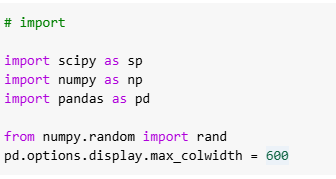

In [2]:
import scipy as sp
import numpy as np
import pandas as pd

from numpy.random import randn
pd.options.display.max_colwidth=600

In [3]:
#

___________________________________________________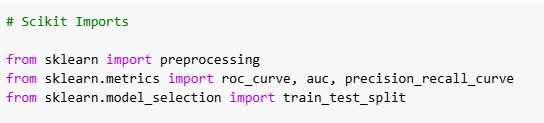

In [4]:
from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc,precision_recall_curve
from sklearn.model_selection import train_test_split



In [5]:
#

__________________________________________________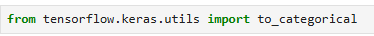

In [6]:
from tensorflow.keras.utils import to_categorical


In [7]:
ls

sample_data/


___________________________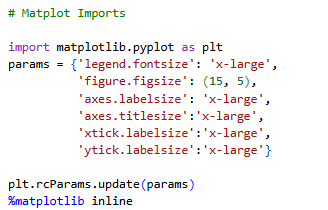

In [8]:
import matplotlib.pyplot as plt
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large'}
plt.rcParams.update(params)
%matplotlib inline

______________________________________________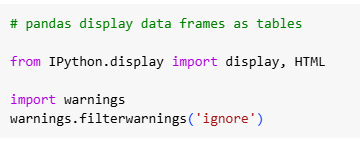

In [9]:
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

In [10]:
#

_________________________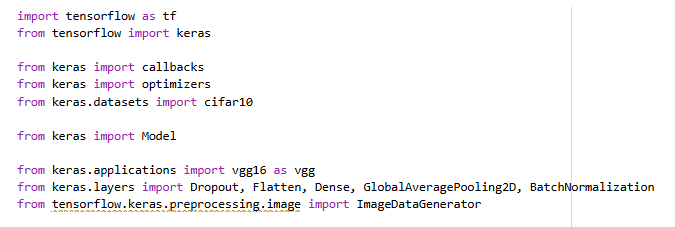

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10

from keras import Model

from keras.applications import vgg16 as vgg
from keras.layers import Dropout, Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [12]:
#

### Load and manipulate the DataSet

____________________________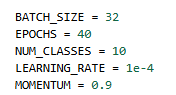

In [13]:
BATCH_SIZE =32
EPOCHS = 40
NUM_CLASSES =10
LEARNING_RATE =1e-4
MOMUNTUM=0.9

In [14]:
#

__________________________________________________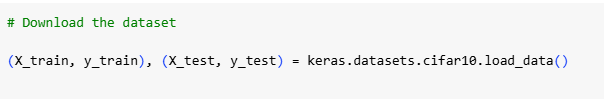

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [16]:
#

__________________________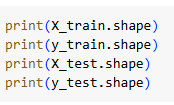

In [17]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [18]:
#

______________________________________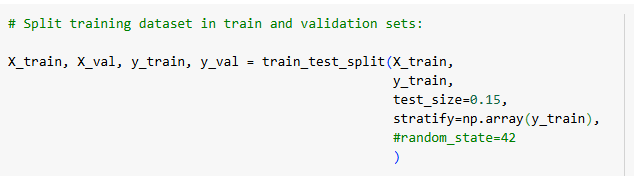

In [19]:
x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                  y_train,
                                                  test_size=0.15,
                                                  stratify=np.array(y_train),
                                                  #random_state=42
                                                  )

In [20]:
#

______________________________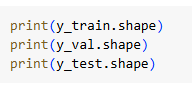

In [21]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(42500, 1)
(7500, 1)
(10000, 1)


In [22]:
#

Checks for free memory:

_____________________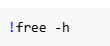

In [23]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.7Gi       6.6Gi       2.0Mi       4.3Gi        10Gi
Swap:             0B          0B          0B


In [24]:
#

______________________________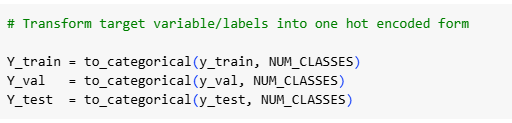

In [25]:
y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

In [26]:
#

____________________________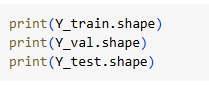

In [27]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(42500, 10)
(7500, 10)
(10000, 10)


In [28]:
#

### Preprocessing

In [29]:
# Since we are about to use VGG16 and VGG19as a feature extractor, the minimum size of an image its take is 48x48.
# We utilize ```scipy`` to resize images to required dimensions


_______________________________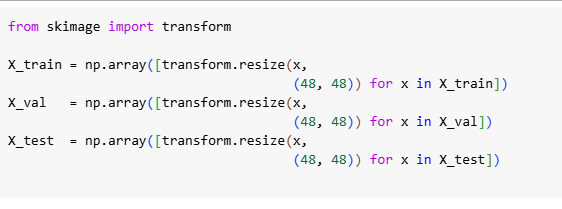

In [30]:
from skimage import transform
x_train = np.array([transform.resize(x,
                                     (48,48)) for x in x_train])
x_val = np.array([transform.resize(x,
                                     (48,48)) for x in x_val])
x_test = np.array([transform.resize(x,
                                     (48,48)) for x in x_test])

In [31]:
#

_____________________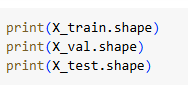

In [32]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(42500, 48, 48, 3)
(7500, 48, 48, 3)
(10000, 48, 48, 3)


In [33]:
#

____________________________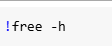

In [34]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       5.1Gi       3.2Gi       2.0Mi       4.3Gi       7.3Gi
Swap:             0B          0B          0B


In [35]:
#

# Create VGG19 Model

- Load VGG16 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_______________________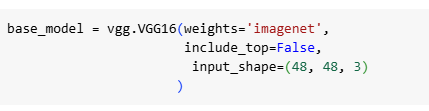

In [36]:
base_model = vgg.VGG16(weights='imagenet',
                       include_top=False,
                       input_shape=(48,48,3
                                    ))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
#

____________________________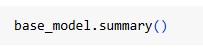

In [38]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
#

________________________________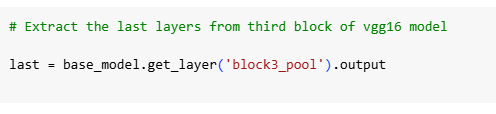

In [40]:
last = base_model.get_layer('block2_pool').output

In [41]:
#

______________________________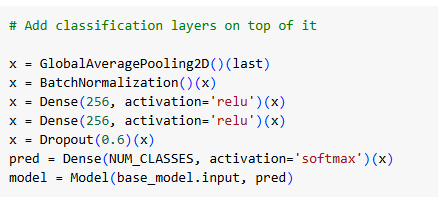

In [42]:
x= GlobalAveragePooling2D()(last)
x  = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x =Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(base_model.input, pred)

In [43]:
#

____________________________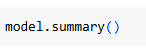

In [44]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,506 (2.27 MB)

 Trainable params: 594,250 (2.27 MB)

 Non-trainable params: 256 (1.00 KB)

In [45]:
#

_____________________________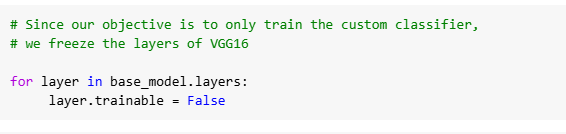

In [46]:
for layer in base_model.layers:
  layer.trainable = False

In [47]:
#

_________________________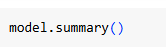

In [48]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,506 (2.27 MB)

 Trainable params: 334,090 (1.27 MB)

 Non-trainable params: 260,416 (1017.25 KB)

In [49]:
#

_______________________________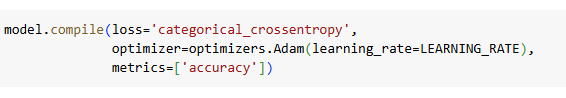

In [50]:
model.compile(loss='categorical_crossentropy',
              optimizer = optimizers.Adam(learning_rate=LEARNING_RATE),
              metrics=['accuracy'])

In [51]:
#

### EarlyStopping

___________________________image.png

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

In [53]:
#

In [54]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 6

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


### Data Augmentation


To help model generalize and overcome the limitations of a small dataset, we prepare augmented datasets using keras  utilities


___________________________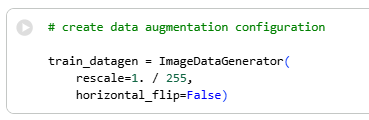

In [55]:
train_datagen = ImageDataGenerator(
    rescale =1. / 255,
    horizontal_flip=False)

In [56]:
#

_________________________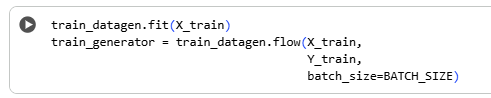

In [57]:
train_datagen.fit(x_train)
train_generator = train_datagen.flow(x_train,
                                     y_train,
                                     batch_size=BATCH_SIZE)

In [58]:
#

__________________________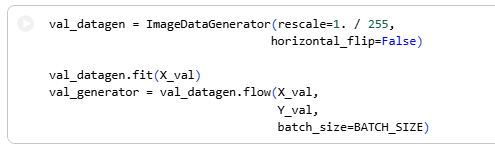

In [59]:
val_datagen = ImageDataGenerator(rescale=1./255,
                                 horizontal_flip=False)
val_datagen.fit(x_val)
val_generator = val_datagen.flow(x_val,
                                 y_val,
                                 batch_size=BATCH_SIZE)


In [60]:
#

### Train the Model

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell
</h4> </html>

In [61]:
train_steps_per_epoch = x_train.shape[0] // BATCH_SIZE
val_steps_per_epoch = x_val.shape[0] // BATCH_SIZE

___________________________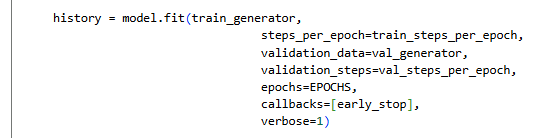

In [62]:
history = model.fit(train_generator,
                    steps_per_epoch=train_steps_per_epoch,
                    validation_data=val_generator,
                    validation_steps=val_steps_per_epoch,
                    epochs=EPOCHS,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3192 - loss: 1.9291 - val_accuracy: 0.4586 - val_loss: 1.5012
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.3125 - loss: 1.6928 - val_accuracy: 0.4601 - val_loss: 1.5008
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4544 - loss: 1.5231 - val_accuracy: 0.5063 - val_loss: 1.3846
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.4062 - loss: 1.5841 - val_accuracy: 0.5055 - val_loss: 1.3848
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4920 - loss: 1.4340 - val_accuracy: 0.5315 - val_loss: 1.3202
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.4375 - loss: 1.6318 - val_accuracy: 0.5312 - val_loss: 1.3202
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5124 - loss: 1.3654 - val_accuracy: 0.5457 - val_loss: 1.2690
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - accuracy: 0.5312 - loss: 

In [63]:
#

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using </h4> </html>

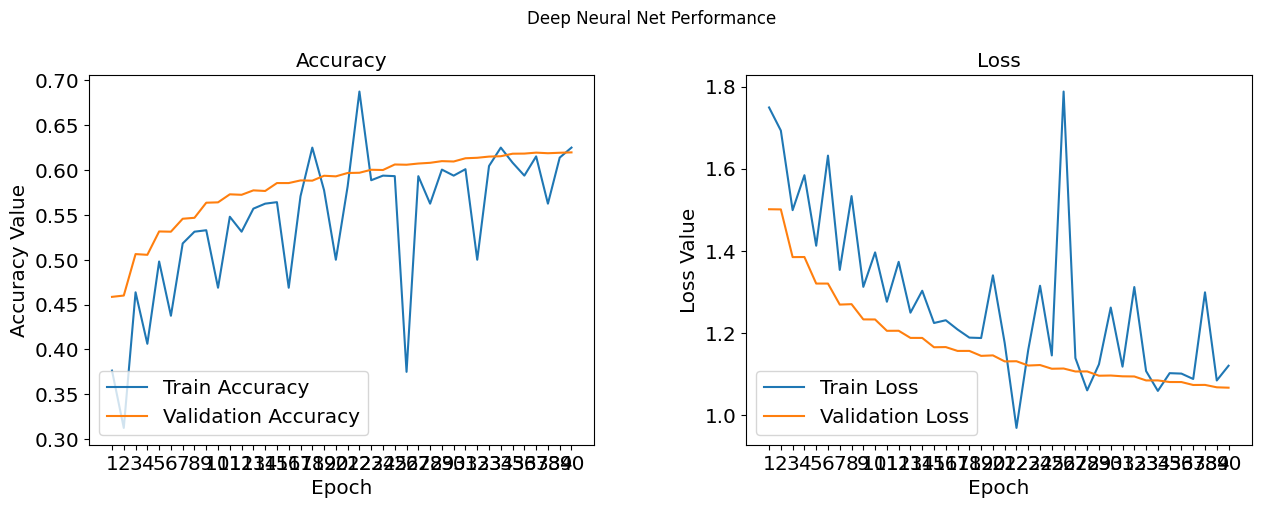

In [64]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(1,EPOCHS+1))
ax1.plot(epochs, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history.history['loss'], label='Train Loss')
ax2.plot(epochs, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


___________________________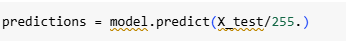

In [65]:
predictions = model.predict(x_test/255.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [66]:
#

_________________________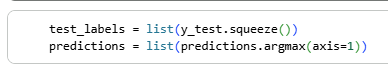

In [67]:
#test_labels = list(y_test.squeeze())
#predictions = list(predictions.argmax(axis=1))

test_labels = np.argmax(y_test, axis=1)
predictions = np.argmax(np.array(predictions), axis=1)

In [68]:
#

___________________________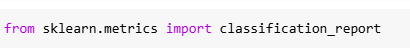

In [69]:
from sklearn.metrics import classification_report

In [70]:
#

___________________________________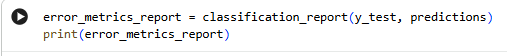

In [71]:
error_metrics_report = classification_report(test_labels, predictions)
print(error_metrics_report)

              precision    recall  f1-score   support

           0       0.67      0.63      0.65      1000
           1       0.71      0.68      0.69      1000
           2       0.59      0.47      0.52      1000
           3       0.46      0.49      0.48      1000
           4       0.58      0.53      0.56      1000
           5       0.58      0.57      0.58      1000
           6       0.63      0.78      0.69      1000
           7       0.68      0.61      0.65      1000
           8       0.70      0.74      0.72      1000
           9       0.63      0.74      0.69      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



In [72]:
#

_________________________________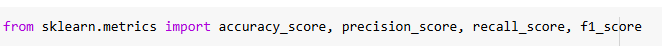

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [74]:
#

________________________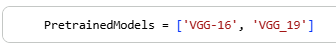

In [75]:
pretrainedModels = ['VGG-16', 'VGG_19']

In [76]:
#

___________________________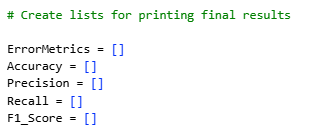

In [77]:
ErrorMetrics = []
Accuracy = []
Precision = []
Recall = []
F1_score = []

In [78]:
#

____________________________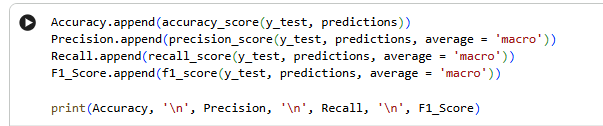

In [79]:
y_test_labels = np.argmax(y_test, axis=1)
Accuracy.append(accuracy_score(y_test_labels, predictions))
Precision.append(precision_score(y_test_labels, predictions, average ='macro'))
Recall.append(recall_score(y_test_labels, predictions, average ='macro'))
F1_score.append(f1_score(y_test_labels, predictions, average ='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_score )

[0.6244] 
 [0.6248553570513609] 
 [0.6244] 
 [0.6222945014603174]


In [80]:
#

### Visualise Predictions

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [81]:
#label_dict = {0:'airplane',
#             1:'automobile',
#             2:'bird',
#             3:'cat',
#             4:'deer',
#             5:'dog',
#             6:'frog',
#             7:'horse',
#             8:'ship',
#             9:'truck'}

classes=['airplane', 'automobile', 'bird', 'cat', 'deer',
 'dog', 'frog', 'houre', 'ship', 'truck']

In [82]:
# Graph this to look at the full set of 10 class predictions.


def plot_image(i,predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(label_dict[predicted_label],
                                    100 * np.max(predictions_array),
                                    label_dict[true_label]),
                                    color=color)

___________________________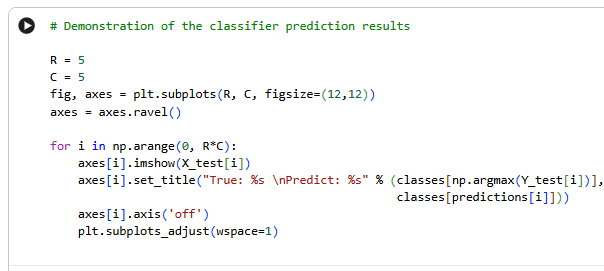

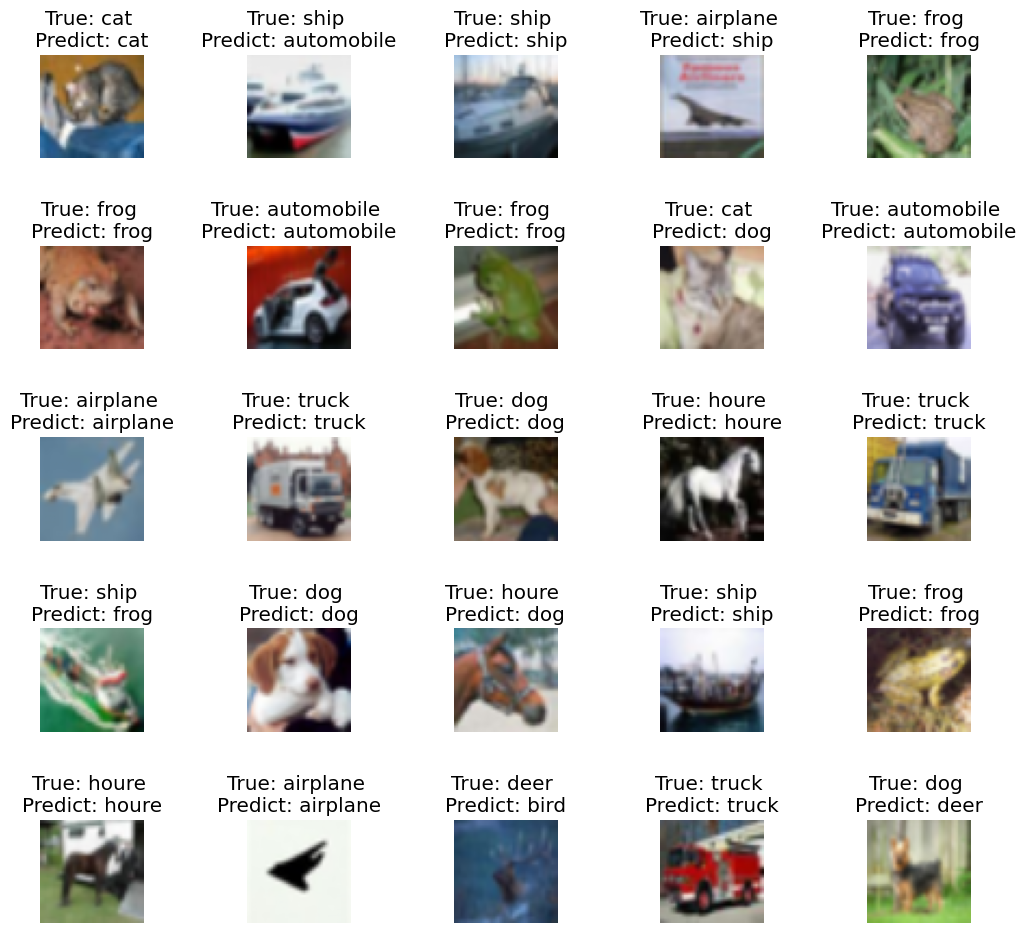

In [83]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize = (12, 12))
axes = axes.ravel()
for i in np.arange(0, R * C):
    axes[i].imshow(x_test[i])
    axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(y_test[i])],
                                                  classes[predictions[i]]))
    axes[i].axis('off')
    plt.subplots_adjust(wspace = 1)

In [84]:
#

# Create VGG19 Model

- Load VGG19 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_________________________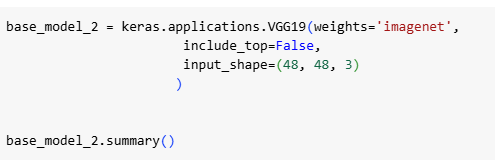

In [85]:
base_model_2 = keras.applications.VGG19(weights='imagenet',
                                        include_top=False,
                                        input_shape=(48, 48, 3)
                                        )
base_model_2.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
#

___________________________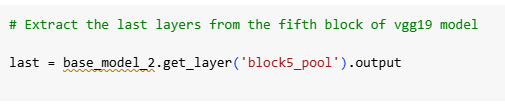

In [87]:
last = base_model_2.get_layer('block5_pool').output

In [88]:
#

_______________________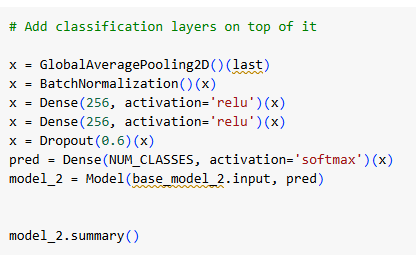

In [89]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)
model_2 = Model(base_model_2.input, pred)

model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,556,874 (78.42 MB)

 Trainable params: 20,555,850 (78.41 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [90]:
#

_________________________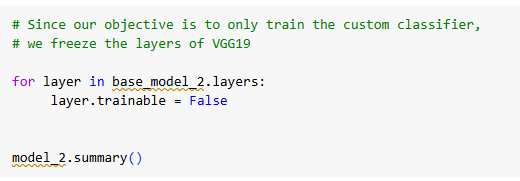

In [91]:
for layer in base_model_2.layers:
  layer.trainable = False

model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,556,874 (78.42 MB)

 Trainable params: 531,466 (2.03 MB)

 Non-trainable params: 20,025,408 (76.39 MB)

In [92]:
#

_______________________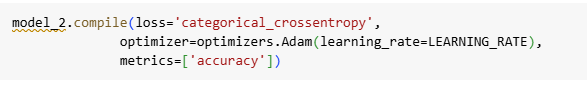

In [93]:
model_2.compile(loss='categorical_crossentropy',
                optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                metrics=['accuracy'])

In [94]:
#

### Train the Model_2

____________________________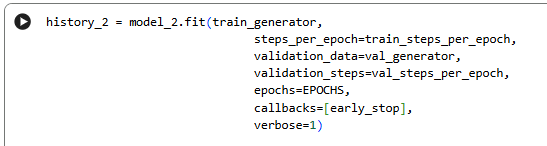

In [95]:
history_2 =model_2.fit(train_generator,
                    steps_per_epoch=train_steps_per_epoch,
                    validation_data= val_generator,
                    validation_steps = val_steps_per_epoch,
                    epochs=EPOCHS,
                    callbacks = [early_stop],
                    verbose=1)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.2444 - loss: 2.1105 - val_accuracy: 0.3523 - val_loss: 1.7610
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2812 - loss: 1.8447 - val_accuracy: 0.3536 - val_loss: 1.7610
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.3480 - loss: 1.7818 - val_accuracy: 0.3916 - val_loss: 1.6700
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3438 - loss: 1.7290 - val_accuracy: 0.3914 - val_loss: 1.6695
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.3793 - loss: 1.7086 - val_accuracy: 0.4180 - val_loss: 1.6107
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4062 - loss: 1.7004 - val_accuracy: 0.4183 - val_loss: 1.6106
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.4018 - loss: 1.6565 - val_accuracy: 0.4328 - val_loss: 1.5726
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3125 - loss: 1

In [96]:
#

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

Find 4 differences in the code with the similar code for VGG16

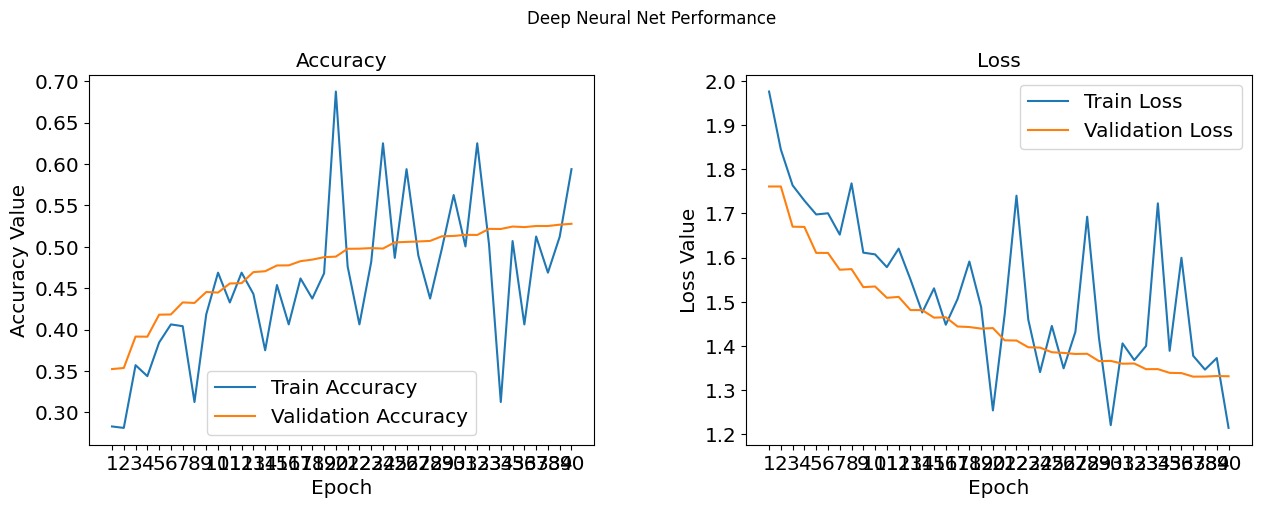

In [97]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epochs = list(range(1,EPOCHS+1))
ax1.plot(epochs, history_2.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(epochs)
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epochs, history_2.history['loss'], label='Train Loss')
ax2.plot(epochs, history_2.history['val_loss'], label='Validation Loss')
ax2.set_xticks(epochs)
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")


_______________________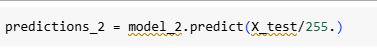

In [98]:
predictions_2 =model_2.predict(x_test/255.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


In [99]:
#

__________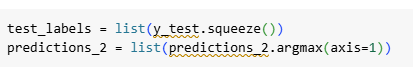

In [100]:
#test_labels = np.argmax(y_test, axis=1)
#predictions_2 = list(predictions_2)

test_labels = np.argmax(y_test, axis=1)
predictions_2 = np.argmax(np.array(predictions_2), axis=1)


In [101]:
#

_____________________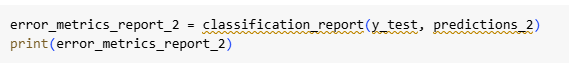

In [102]:
error_metrics_report_2 = classification_report(test_labels, predictions_2)
print(error_metrics_report_2)

              precision    recall  f1-score   support

           0       0.55      0.60      0.57      1000
           1       0.63      0.64      0.63      1000
           2       0.39      0.41      0.40      1000
           3       0.37      0.28      0.32      1000
           4       0.45      0.42      0.43      1000
           5       0.46      0.41      0.43      1000
           6       0.53      0.60      0.56      1000
           7       0.62      0.55      0.58      1000
           8       0.61      0.76      0.67      1000
           9       0.59      0.58      0.59      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



In [103]:
#

________________________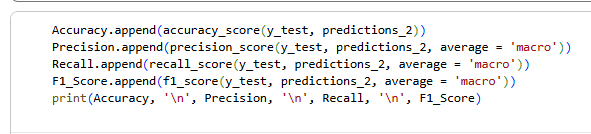

In [104]:
Accuracy.append(accuracy_score(y_test_labels, predictions))
Precision.append(precision_score(y_test_labels, predictions, average ='macro'))
Recall.append(recall_score(y_test_labels, predictions, average ='macro'))
F1_score.append(f1_score(y_test_labels, predictions, average ='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_score )


[0.6244, 0.6244] 
 [0.6248553570513609, 0.6248553570513609] 
 [0.6244, 0.6244] 
 [0.6222945014603174, 0.6222945014603174]


In [105]:
#

_______________________________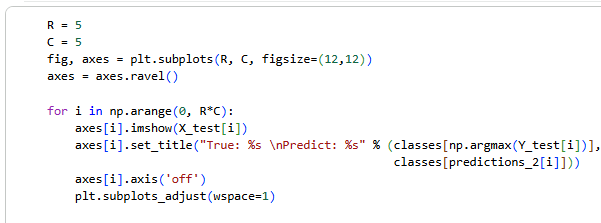

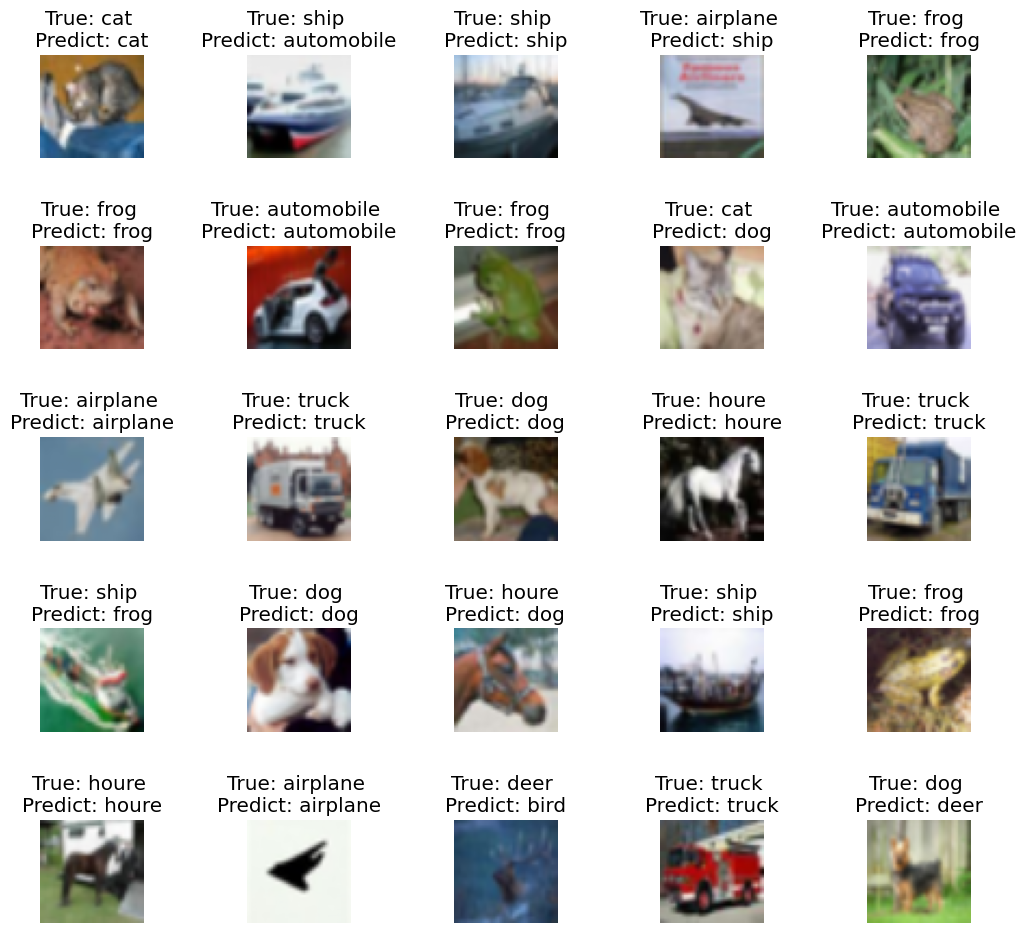

In [106]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize = (12, 12))
axes = axes.ravel()
for i in np.arange(0, R * C):
    axes[i].imshow(x_test[i])
    axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(y_test[i])],
                                                  classes[predictions[i]]))
    axes[i].axis('off')
    plt.subplots_adjust(wspace = 1)

In [107]:
#

_______________________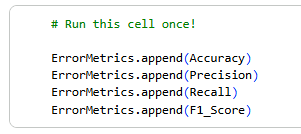

In [108]:
ErrorMetrics.append(Accuracy)
ErrorMetrics.append(Precision)
ErrorMetrics.append(Recall)
ErrorMetrics.append(F1_score)

In [109]:
#

________________________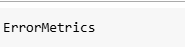

In [110]:
ErrorMetrics

[[0.6244, 0.6244],
 [0.6248553570513609, 0.6248553570513609],
 [0.6244, 0.6244],
 [0.6222945014603174, 0.6222945014603174]]

In [111]:
#

_________________________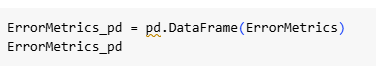

In [112]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd

,0,1
0,0.624400,0.624400
1,0.624855,0.624855
2,0.624400,0.624400
3,0.622295,0.622295


In [113]:
#

_____________________________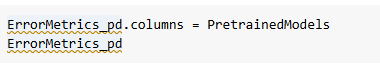

In [114]:
ErrorMetrics_pd.columns = pretrainedModels
ErrorMetrics_pd

,VGG-16,VGG_19
0,0.624400,0.624400
1,0.624855,0.624855
2,0.624400,0.624400
3,0.622295,0.622295


In [115]:
#

___________________________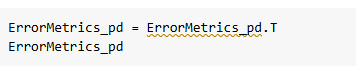

In [117]:
ErrorMetrics_pd = ErrorMetrics_pd.T
ErrorMetrics_pd

,0,1,2,3
VGG-16,0.6244,0.624855,0.6244,0.622295
VGG_19,0.6244,0.624855,0.6244,0.622295


In [ ]:
#

__________________________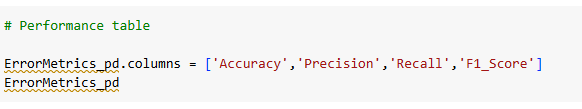

In [118]:
ErrorMetrics_pd.columns = ['Accuracy', 'Prediction', 'Recall', 'F1_score']
ErrorMetrics_pd

,Accuracy,Prediction,Recall,F1_score
VGG-16,0.6244,0.624855,0.6244,0.622295
VGG_19,0.6244,0.624855,0.6244,0.622295


_________________________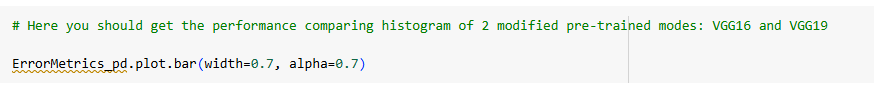

<Axes: >

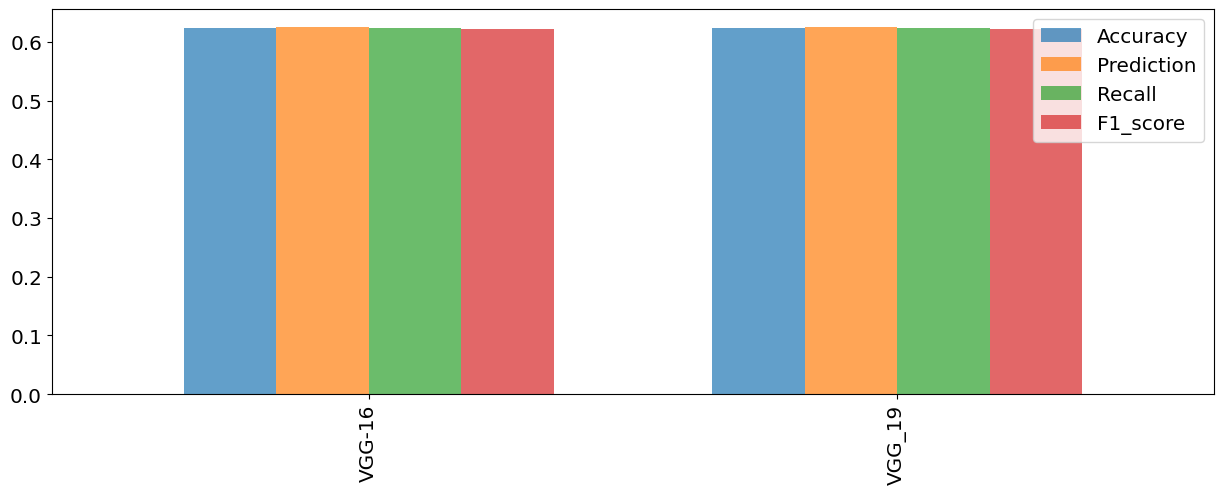

In [119]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot graphs for Accuracy and Loss Function for VGG16 and VGG19 (4 graphs in total).
### 2. Based on this analysis, determine the optimal number of epochs for training your VGG16 and VGG19 models.
### 3. Copy your early-stop code

### 4. Add the final Performance Table

### 5. Plot the performance comparing histogram of VGG16 and VGG19

<html> <h2 style="font-style:bold; color:red;"> Optional.
Extra mark. </h2> </html>

1. Use the base_model 'Inception-V3' pre-trained neural network model.
2. Add Inception-V3 results to the Performance table and Performance comparing histogram.